In [5]:
# Force clean reinstall of transformers
!pip install --force-reinstall transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
!pip install gensim nltk transformers torch scipy matplotlib seaborn requests beautifulsoup4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.3 MB/s eta 0:00:00


In [2]:
import requests
from bs4 import BeautifulSoup
import re

url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, "html.parser")

# Extract all paragraph text
paragraphs = soup.find_all("p")
article_text = " ".join([p.get_text() for p in paragraphs])
article_text = re.sub(r'\s+', ' ', article_text).strip()

print(f"Total characters extracted: {len(article_text)}")
print(article_text[:500])

Total characters extracted: 121441
Front. Sustain. Cities, 11 January 2024 Sec. Climate Change and Cities Volume 5 - 2023 | https://doi.org/10.3389/frsc.2023.1308684 Frontiers in Sustainable Cities Part of a Research Topic Towards 2030: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action Edited by Ravindra Khaiwal Post Graduate Institute of Medical Education and Research (PGIMER), India Reviewed by Teerachai Amnuaylojaroen University of Phayao, Thailand Akash Biswal Research Institute fo


In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Split article into sentences
sentences = sent_tokenize(article_text)

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t.isalpha() and t not in stop_words and len(t) > 3]
    return tokens

tokenized_docs = [preprocess(sent) for sent in sentences if len(sent.split()) > 10]
print(f"Number of documents (sentences): {len(tokenized_docs)}")
print("Sample tokenized doc:", tokenized_docs[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Number of documents (sentences): 573
Sample tokenized doc: ['climate', 'change', 'city', 'volume', 'http', 'frontier', 'sustainable', 'city', 'part', 'research', 'topic', 'towards', 'sustainable', 'city', 'perspective', 'achieving', 'sustainable', 'development', 'goal', 'climate', 'action', 'edited', 'ravindra', 'khaiwal', 'post', 'graduate', 'institute', 'medical', 'education', 'research', 'pgimer', 'india', 'reviewed', 'teerachai', 'amnuaylojaroen', 'university', 'phayao', 'thailand', 'akash', 'biswal', 'research', 'institute', 'humanity', 'nature', 'japan', 'outline', 'abstract', 'introduction', 'status', 'climate', 'change', 'india', 'climate', 'change', 'impact', 'climate', 'change', 'related', 'extreme', 'event', 'india', 'india', 'urban', 'transformation', 'climate', 'change', 'vulnerable', 'community', 'global', 'climate', 'climate', 'change', 'mitigation', 'status', 'strategy', 'india', 'conclusion', 'future', 'direction', 'climate', 'change', 'study', 'india', 'author', 'cont

In [4]:
from gensim import corpora, models

# Build dictionary and corpus
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=2, no_above=0.9)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

# LDA Model
NUM_TOPICS = 5
lda_model = models.LdaModel(corpus, num_topics=NUM_TOPICS, id2word=dictionary,
                              passes=20, random_state=42)

print("=" * 60)
print("LDA TOPICS")
print("=" * 60)
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx + 1}: {topic}")

LDA TOPICS

Topic 1: 0.031*"india" + 0.018*"change" + 0.018*"climate" + 0.017*"forest" + 0.016*"global" + 0.011*"population" + 0.010*"precipitation" + 0.009*"increase" + 0.009*"health" + 0.008*"world"

Topic 2: 0.066*"climate" + 0.054*"change" + 0.028*"impact" + 0.025*"india" + 0.018*"urban" + 0.016*"city" + 0.013*"pollution" + 0.013*"challenge" + 0.009*"adaptation" + 0.008*"sustainable"

Topic 3: 0.019*"climate" + 0.013*"india" + 0.013*"water" + 0.012*"urban" + 0.011*"sustainable" + 0.011*"pollution" + 0.011*"effect" + 0.010*"risk" + 0.010*"level" + 0.009*"city"

Topic 4: 0.023*"india" + 0.016*"climate" + 0.014*"change" + 0.013*"temperature" + 0.012*"urban" + 0.009*"emission" + 0.009*"carbon" + 0.009*"heat" + 0.009*"significant" + 0.009*"land"

Topic 5: 0.021*"temperature" + 0.018*"climate" + 0.013*"forest" + 0.011*"year" + 0.009*"change" + 0.009*"sonwani" + 0.008*"area" + 0.008*"report" + 0.007*"saxena" + 0.007*"rainfall"


In [5]:
# TF-IDF transformation before LSI
tfidf = models.TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

# LSI Model
lsi_model = models.LsiModel(corpus_tfidf, id2word=dictionary, num_topics=NUM_TOPICS)

print("=" * 60)
print("LSI TOPICS")
print("=" * 60)
for idx, topic in lsi_model.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"\nTopic {idx + 1}: {topic}")

LSI TOPICS

Topic 1: -0.292*"change" + -0.289*"climate" + -0.220*"impact" + -0.204*"india" + -0.185*"urban" + -0.166*"city" + -0.163*"pollution" + -0.133*"effect" + -0.129*"forest" + -0.129*"global"

Topic 2: 0.241*"temperature" + -0.217*"city" + 0.195*"emission" + 0.181*"forest" + -0.158*"urban" + -0.151*"mitigation" + 0.150*"increase" + -0.150*"sustainable" + -0.146*"adaptation" + -0.134*"strategy"

Topic 3: 0.346*"urban" + -0.246*"change" + 0.216*"temperature" + 0.208*"green" + -0.204*"global" + -0.195*"climate" + -0.189*"pollution" + -0.170*"impact" + 0.168*"heat" + 0.154*"infrastructure"

Topic 4: -0.485*"emission" + -0.285*"carbon" + -0.266*"dioxide" + -0.174*"energy" + -0.148*"statista" + -0.142*"fossil" + -0.135*"fuel" + 0.128*"indian" + 0.127*"temperature" + -0.124*"global"

Topic 5: -0.426*"forest" + 0.284*"pollution" + 0.229*"health" + -0.194*"fire" + -0.183*"indian" + -0.163*"vegetation" + 0.139*"environmental" + -0.138*"city" + 0.137*"extreme" + 0.136*"global"


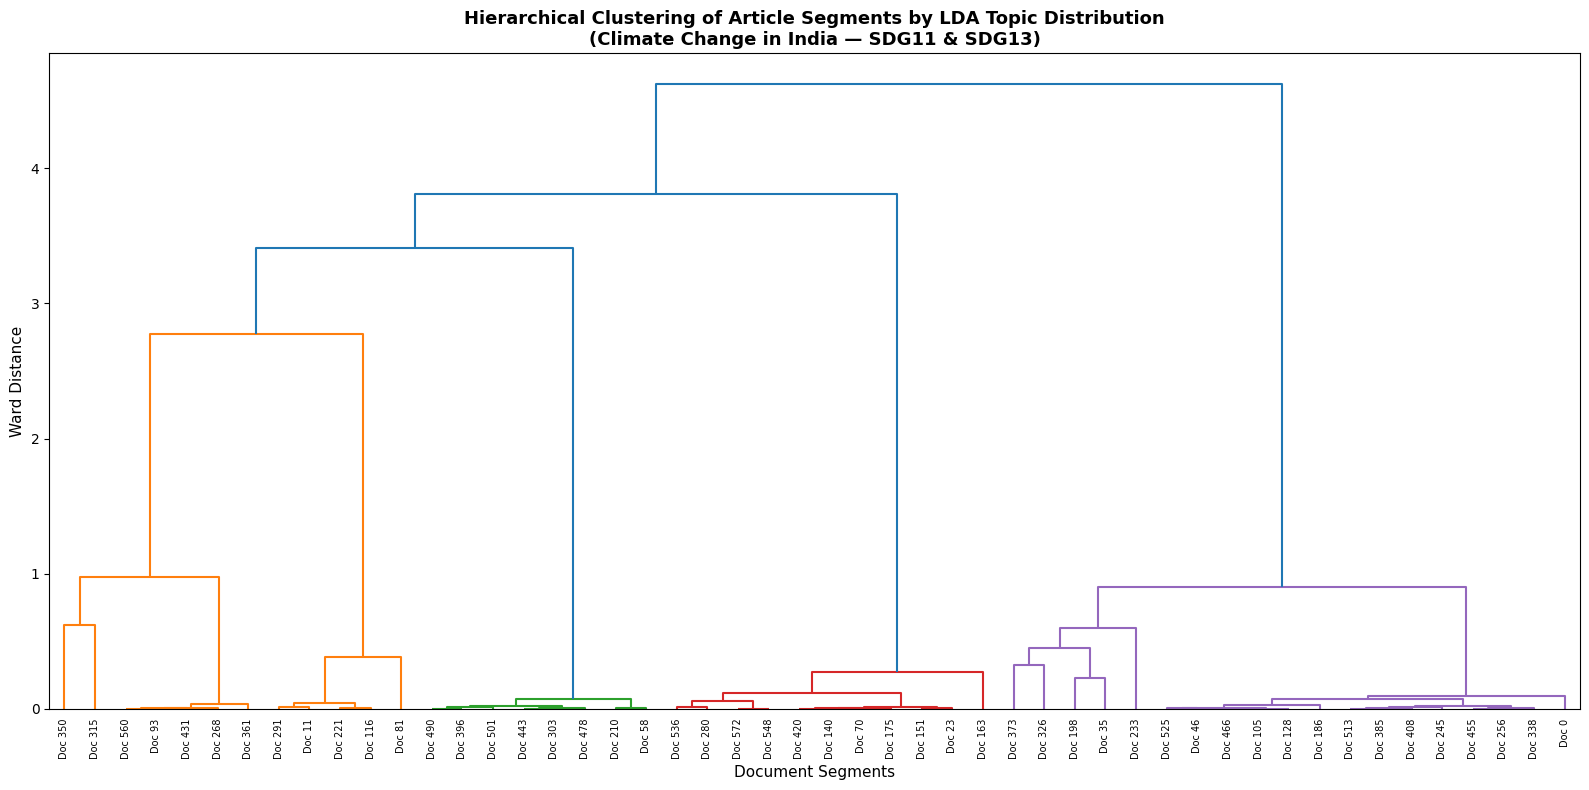

Dendrogram saved as 'hierarchical_clustering.png'


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cosine

# Get LDA topic vectors for each document
def get_topic_vector(bow, model, num_topics):
    topics = dict(model.get_document_topics(bow, minimum_probability=0))
    return [topics.get(i, 0) for i in range(num_topics)]

doc_topic_matrix = np.array([get_topic_vector(bow, lda_model, NUM_TOPICS) for bow in corpus])

# Sample 50 sentences for clarity
sample_size = min(50, len(doc_topic_matrix))
sample_idx = np.linspace(0, len(doc_topic_matrix)-1, sample_size, dtype=int)
sampled_matrix = doc_topic_matrix[sample_idx]
sampled_labels = [f"Doc {i}" for i in sample_idx]

# Topic labels for legend
topic_labels = [f"Topic {i+1}" for i in range(NUM_TOPICS)]

# Hierarchical clustering
linked = linkage(sampled_matrix, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(linked,
           orientation='top',
           labels=sampled_labels,
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=7,
           color_threshold=0.7 * max(linked[:, 2]))

plt.title("Hierarchical Clustering of Article Segments by LDA Topic Distribution\n(Climate Change in India — SDG11 & SDG13)", fontsize=13, fontweight='bold')
plt.xlabel("Document Segments", fontsize=11)
plt.ylabel("Ward Distance", fontsize=11)
plt.tight_layout()
plt.savefig("hierarchical_clustering.png", dpi=150)
plt.show()
print("Dendrogram saved as 'hierarchical_clustering.png'")

In [7]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

# Load DistilBART directly
model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

# Chunk and tokenize
chunk = article_text[:1024]
inputs = tokenizer(chunk, return_tensors="pt", max_length=1024, truncation=True)

# Generate summary
summary_ids = model.generate(
    inputs["input_ids"],
    max_length=250,
    min_length=80,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

summary_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("=" * 60)
print("LLM SUMMARY (DistilBART)")
print("=" * 60)
print(summary_text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

LLM SUMMARY (DistilBART)
 Frontiers in Sustainable Cities: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action . The study was part of a research Topic Towards 2030: A sustainable Cities Perspective . The author contributed funding conflicts of interest in the author's conflict of interest . The research was conducted by Ravindra Khaiwal and Teerachai Amnuaylojaroen of the University of Phayao, Thailand .


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline
import numpy as np
import re

# Top 5 Keywords via TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
X = vectorizer.fit_transform([article_text])
tfidf_scores = np.array(X.todense()).flatten()
feature_names = vectorizer.get_feature_names_out()
top5_idx = tfidf_scores.argsort()[-5:][::-1]

print("=" * 60)
print("TOP 5 KEYWORDS (TF-IDF)")
print("=" * 60)
for i, idx in enumerate(top5_idx):
    print(f"  {i+1}. {feature_names[idx]}  (score: {tfidf_scores[idx]:.4f})")

# Zero-Shot Classification
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = [
    "Climate Change Impacts",
    "Air Pollution and Emissions",
    "Urban Sustainability and SDGs",
    "Extreme Weather Events",
    "Climate Mitigation and Renewable Energy"
]

result = classifier(article_text[:1000], candidate_labels)

print("\n" + "=" * 60)
print("ZERO-SHOT TOPIC CLASSIFICATION (Transformers)")
print("=" * 60)
for label, score in zip(result['labels'], result['scores']):
    print(f"  {label}: {score:.4f}")

TOP 5 KEYWORDS (TF-IDF)
  1. climate  (score: 0.4433)
  2. change  (score: 0.3043)
  3. climate change  (score: 0.2897)
  4. india  (score: 0.2619)
  5. al  (score: 0.2370)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


ZERO-SHOT TOPIC CLASSIFICATION (Transformers)
  Climate Change Impacts: 0.6990
  Urban Sustainability and SDGs: 0.1460
  Extreme Weather Events: 0.0939
  Climate Mitigation and Renewable Energy: 0.0373
  Air Pollution and Emissions: 0.0238
